In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [2]:
# Load Dataset
df = pd.read_csv('Student_data.csv')

df.head()

,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,attendance_percentage,primary_language,DSA_problems_solved,GitHub_repos,hackathons_participated,development_projects_count,AI_ML_projects,internships_completed,resume_score,communication_skills,aptitude_score,mock_interview_score,sleep_hours,screen_time,gaming_hours,study_hours_daily,stress_level,burnout_score,gym_frequency,family_income_lpa,self_learning_hours,motivation_level,placement_status,company_type,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
0,STU00001,22,Male,Karnataka,1,2,Computer Science,MCA,6.71,3,75.5,C++,656,10.0,2,5,0,1,55,97,100,NaN,5.7,7.7,1.5,8.0,71,34,0,5.00,2.7,60,Placed,Startup,Remote,17.36,4,1,2,62,55,55,19,81
1,STU00002,20,Male,Tamil Nadu,2,3,AI & DS,BTech,6.14,0,84.4,Rust,619,16.0,1,7,1,6,100,64,97,80.0,5.3,8.2,0.1,5.7,52,58,6,2.47,4.3,82,Placed,MNC,Onsite,18.22,3,3,0,55,66,52,54,76
2,STU00003,23,Female,Uttar Pradesh,3,2,Computer Science,BTech,7.11,0,80.6,Java,674,30.0,3,10,5,3,100,93,83,81.0,4.9,8.3,0.0,7.2,47,50,5,3.65,3.5,50,Placed,Startup,Remote,22.08,1,3,1,79,69,67,49,34
3,STU00004,25,Male,Maharashtra,2,3,Civil,BTech,7.41,0,69.2,Rust,637,15.0,3,7,5,3,87,100,96,100.0,6.4,8.7,2.4,7.7,47,41,2,4.40,3.7,67,Placed,Product-Based,Remote,20.87,2,1,2,44,44,65,61,46
4,STU00005,25,Female,West Bengal,3,3,Civil,BE,8.29,0,76.6,Java,986,12.0,0,2,1,1,68,100,84,68.0,4.8,6.9,3.6,10.2,40,68,2,12.11,4.9,66,Placed,Startup,Onsite,20.57,5,3,5,23,57,67,71,44


In [ ]:
# Basic Exploration
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

df.columns

(25000, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  25000 non-null  object 
 1   age                         25000 non-null  int64  
 2   gender                      25000 non-null  object 
 3   state                       25000 non-null  object 
 4   city_tier                   25000 non-null  int64  
 5   college_tier                25000 non-null  int64  
 6   branch                      25000 non-null  object 
 7   degree                      25000 non-null  object 
 8   cgpa                        25000 non-null  float64
 9   backlog_history             25000 non-null  int64  
 10  attendance_percentage       25000 non-null  float64
 11  primary_language            25000 non-null  object 
 12  DSA_problems_solved         25000 non-null  int64  
 13  GitHub_repos       

Index(['student_id', 'age', 'gender', 'state', 'city_tier', 'college_tier',
       'branch', 'degree', 'cgpa', 'backlog_history', 'attendance_percentage',
       'primary_language', 'DSA_problems_solved', 'GitHub_repos',
       'hackathons_participated', 'development_projects_count',
       'AI_ML_projects', 'internships_completed', 'resume_score',
       'communication_skills', 'aptitude_score', 'mock_interview_score',
       'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily',
       'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa',
       'self_learning_hours', 'motivation_level', 'placement_status',
       'company_type', 'work_mode', 'salary_lpa', 'interview_rounds_cleared',
       'offer_count', 'joining_delay_months', 'layoffs_risk_score',
       'AI_tool_usage_frequency', 'prompt_engineering_skill', 'AI_fear_score',
       'adaptability_score'],
      dtype='object')

In [ ]:
# Checking Target Variable
df['salary_lpa'].describe()

,salary_lpa
count,25000.000000
mean,19.006936
std,4.244388
min,0.000000
25%,16.750000
50%,19.130000
75%,21.570000
max,35.100000


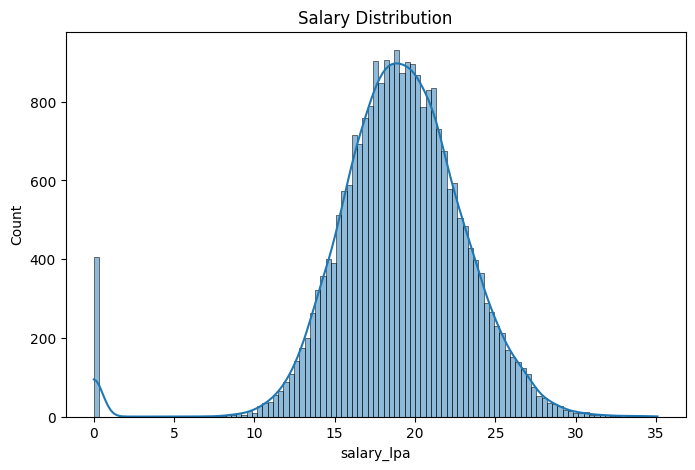

In [ ]:
# Plotting a Histogram to identify salary distribution
plt.figure(figsize=(8,5))
sns.histplot(df['salary_lpa'], kde=True)
plt.title('Salary Distribution')
plt.show()

In [ ]:
# Checking whether all students with salary = 0 are "Not Placed
(df['salary_lpa'] == 0).sum()

np.int64(404)

In [ ]:
df[df['salary_lpa'] == 0][['placement_status', 'salary_lpa']].head()

,placement_status,salary_lpa
176,Not Placed,0.0
185,Not Placed,0.0
271,Not Placed,0.0
275,Not Placed,0.0
308,Not Placed,0.0


In [ ]:
pd.crosstab(
    df['placement_status'],
    df['salary_lpa'] == 0
)

salary_lpa,False,True
placement_status,,
Not Placed,0,404
Placed,24596,0


In [ ]:
df.shape

(25000, 44)

In [3]:
#crating a data frame containing only placed studnets
salary_df = df[df['salary_lpa'] > 0].copy()

print(salary_df.shape)

(24596, 44)


In [4]:
salary_df['placement_status'].value_counts()

,count
placement_status,
Placed,24596


In [5]:
(salary_df['salary_lpa'] == 0).sum()

np.int64(0)